In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import tensorflow as tf


In [2]:
dataset_path = '/content/drive/MyDrive/DATASET'

In [3]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
SEED = 42

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

Found 932 files belonging to 3 classes.
Using 746 files for training.
Found 932 files belonging to 3 classes.
Using 186 files for validation.


In [6]:
class_names = train_ds.class_names
print(class_names)

['Limestone', 'Sandstone', 'Shale']


In [7]:
num_classes = len(class_names)
print(num_classes)

3


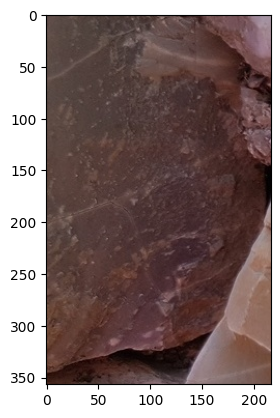

In [8]:
import matplotlib.image as mping
img = mping.imread('/content/drive/MyDrive/DATASET/Shale/01083140015302823767642_rock_0.jpg')
plt.imshow(img)

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)


In [10]:
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x,y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x,y: (normalization_layer(x), y))

In [57]:
data_augumentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2)
])

In [58]:
model = tf.keras.Sequential([
    data_augumentation,
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(3,activation='softmax')

])

In [59]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy,
    metrics=['accuracy']
)

In [60]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_8 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks = [early_stopping]

)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 271s 11s/step - accuracy: 0.4745 - loss: 1.1767 - val_accuracy: 0.5376 - val_loss: 0.9491
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 122s 5s/step - accuracy: 0.5416 - loss: 0.9360 - val_accuracy: 0.4140 - val_loss: 0.9355
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 112s 5s/step - accuracy: 0.5362 - loss: 0.9290 - val_accuracy: 0.6075 - val_loss: 0.8383
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 140s 5s/step - accuracy: 0.5724 - loss: 0.8899 - val_accuracy: 0.5484 - val_loss: 0.8845
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 141s 4s/step - accuracy: 0.5979 - loss: 0.8798 - val_accuracy: 0.6075 - val_loss: 0.8200
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 111s 5s/step - accuracy: 0.6180 - loss: 0.8287 - val_accuracy: 0.6720 - val_loss: 0.7217
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 149s 5s/step - accuracy: 0.6019 - loss: 0.8466 - val_accuracy: 0.7043 - val_loss: 0.7712
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 135s 5s/step - accuracy: 0.6273 - loss: 0.8226 - val_accuracy: 0.6613 - 

In [16]:
loss , accuracy = model.evaluate(val_ds)
print('Test accuracy :', accuracy)
print('validation loss:',loss)

6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 912ms/step - accuracy: 0.7527 - loss: 0.6868
Test accuracy : 0.7526881694793701
validation loss: 0.68678879737854


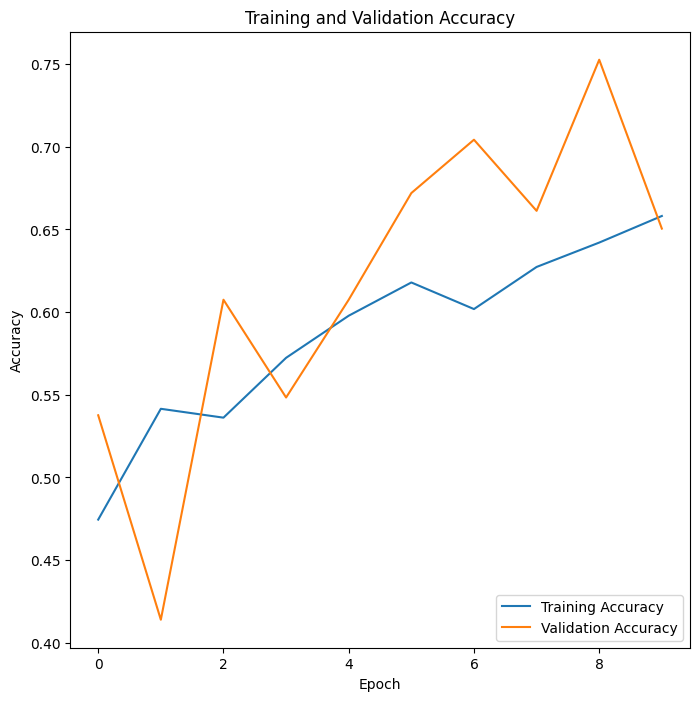

In [17]:
plt.figure(figsize=(8,8))
plt.plot(history.history['accuracy'],label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'],label = 'Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.show()

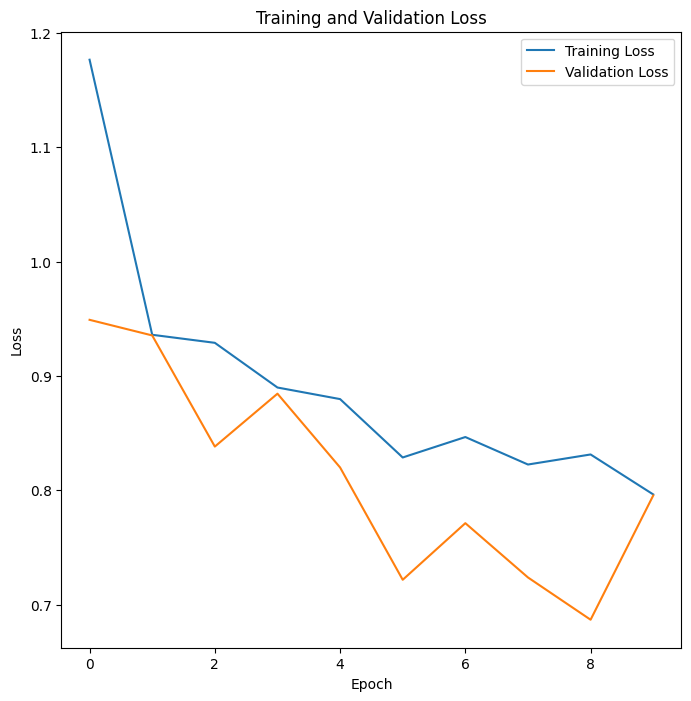

In [18]:
plt.figure(figsize=(8,8))
plt.plot(history.history['loss'],label = 'Training Loss')
plt.plot(history.history['val_loss'],label = 'Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [19]:
for images,labels in val_ds.take(1):
  predictions = model.predict(images)
  predicted_labels = np.argmax(predictions, axis=1)
  actual = class_names[labels[2].numpy()]
  predicted = class_names[predicted_labels[2]]
print('Actual Labels:', actual)
print('Predicted Labels:', predicted)



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 973ms/step
Actual Labels: Limestone
Predicted Labels: Limestone


In [20]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = model.predict(images)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 870ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 867ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 874ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 920ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 824ms/step


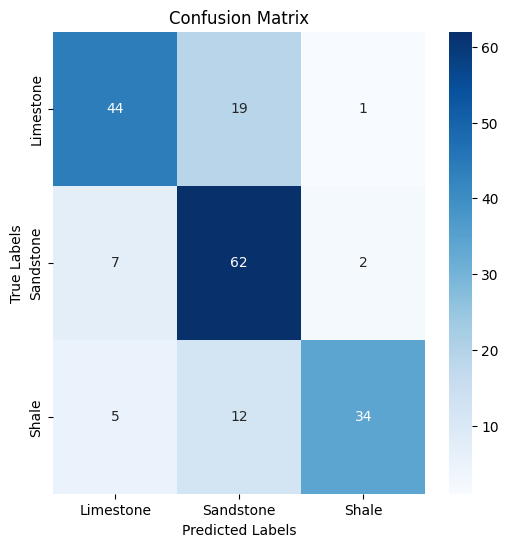

In [21]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [22]:
print(classification_report(y_true, y_pred, target_names=class_names))


              precision    recall  f1-score   support

   Limestone       0.79      0.69      0.73        64
   Sandstone       0.67      0.87      0.76        71
       Shale       0.92      0.67      0.77        51

    accuracy                           0.75       186
   macro avg       0.79      0.74      0.75       186
weighted avg       0.78      0.75      0.75       186



In [23]:

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models




In [25]:
base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [26]:
model_eff = models.Sequential([
    data_augumentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')
])

In [27]:
model_eff.compile(
    loss  = tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    metrics = ['accuracy']
)

In [28]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,508,043 (127.82 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,338,696 (85.22 MB)

In [61]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1)


In [49]:
history_eff = model_eff.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks = [early_stopping, reduce_lr]

)

Epoch 1/15
 2/24 ━━━━━━━━━━━━━━━━━━━━ 1:08 3s/step - accuracy: 0.3281 - loss: 1.1233

KeyboardInterrupt: 

In [31]:
for images, labels in train_ds.take(1):
    print("Shape:", images.shape)
    print("Dtype:", images.dtype)
    print("Min:", tf.reduce_min(images).numpy())
    print("Max:", tf.reduce_max(images).numpy())
    print("Labels:", labels[:10].numpy())

Shape: (32, 224, 224, 3)
Dtype: <dtype: 'float32'>
Min: 0.0
Max: 1.0
Labels: [0 1 2 1 0 1 1 1 0 1]


In [32]:
print(class_names)

['Limestone', 'Sandstone', 'Shale']


In [64]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models

In [65]:
base_model = MobileNetV2(include_top=False, weights='imagenet', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
base_model.trainable = False

In [66]:
model_mobile = models.Sequential([
    data_augumentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(3, activation='softmax')
])

In [67]:
model_mobile.compile(
    loss  = tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    metrics = ['accuracy']
)

In [68]:
model_mobile.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_8 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [69]:
history_mobile = model_mobile.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks = [early_stopping, reduce_lr]

)

Epoch 1/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 77s 3s/step - accuracy: 0.3981 - loss: 1.2469 - val_accuracy: 0.6505 - val_loss: 0.8497 - learning_rate: 1.0000e-04
Epoch 2/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.5483 - loss: 0.9518 - val_accuracy: 0.7097 - val_loss: 0.7112 - learning_rate: 1.0000e-04
Epoch 3/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.6126 - loss: 0.8454 - val_accuracy: 0.7097 - val_loss: 0.6808 - learning_rate: 1.0000e-04
Epoch 4/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.6609 - loss: 0.7760 - val_accuracy: 0.7419 - val_loss: 0.6297 - learning_rate: 1.0000e-04
Epoch 5/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.6863 - loss: 0.7074 - val_accuracy: 0.7366 - val_loss: 0.6259 - learning_rate: 1.0000e-04
Epoch 6/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.7292 - loss: 0.6600 - val_accuracy: 0.7366 - val_loss: 0.6134 - learning_rate: 1.0000e-04
Epoch 7/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.7346 - loss:

In [53]:
base_model.trainable = True

In [54]:
for layer in base_model.layers[:30]:
  layers.trainable = False

In [55]:
model_mobile.compile(
    loss  = tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5),
    metrics = ['accuracy']
)

In [62]:
history_fine = model_mobile.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks = [early_stopping, reduce_lr]
)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 207s 9s/step - accuracy: 0.4732 - loss: 1.0755 - val_accuracy: 0.5054 - val_loss: 0.9848 - learning_rate: 1.0000e-05
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 209s 9s/step - accuracy: 0.5509 - loss: 0.9784 - val_accuracy: 0.5538 - val_loss: 0.9107 - learning_rate: 1.0000e-05
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 207s 9s/step - accuracy: 0.5925 - loss: 0.8927 - val_accuracy: 0.5914 - val_loss: 0.8573 - learning_rate: 1.0000e-05
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 209s 9s/step - accuracy: 0.6059 - loss: 0.8517 - val_accuracy: 0.6022 - val_loss: 0.8136 - learning_rate: 1.0000e-05
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 199s 8s/step - accuracy: 0.6394 - loss: 0.7993 - val_accuracy: 0.6183 - val_loss: 0.7865 - learning_rate: 1.0000e-05
Epoch 6/10
 9/24 ━━━━━━━━━━━━━━━━━━━━ 2:10 9s/step - accuracy: 0.6792 - loss: 0.7323

KeyboardInterrupt: 

In [70]:
model_mobile.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_8 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,751,051 (10.49 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 328,712 (1.25 MB)

In [71]:
test_loss, test_accuracy = model_mobile.evaluate(val_ds)

print("Validation Loss:", test_loss)
print("Validation Accuracy:", test_accuracy)

6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.7419 - loss: 0.6013
Validation Loss: 0.6012883186340332
Validation Accuracy: 0.7419354915618896


In [72]:


y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = model_mobile.predict(images, verbose=0)

    predicted = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

   Limestone       0.66      0.86      0.75        64
   Sandstone       0.76      0.82      0.79        71
       Shale       0.93      0.49      0.64        51

    accuracy                           0.74       186
   macro avg       0.78      0.72      0.73       186
weighted avg       0.77      0.74      0.73       186



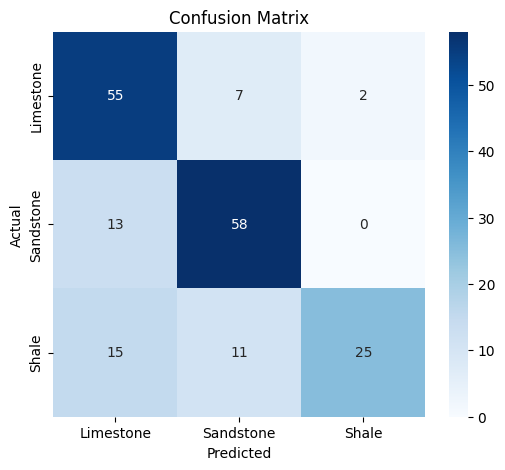

In [73]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

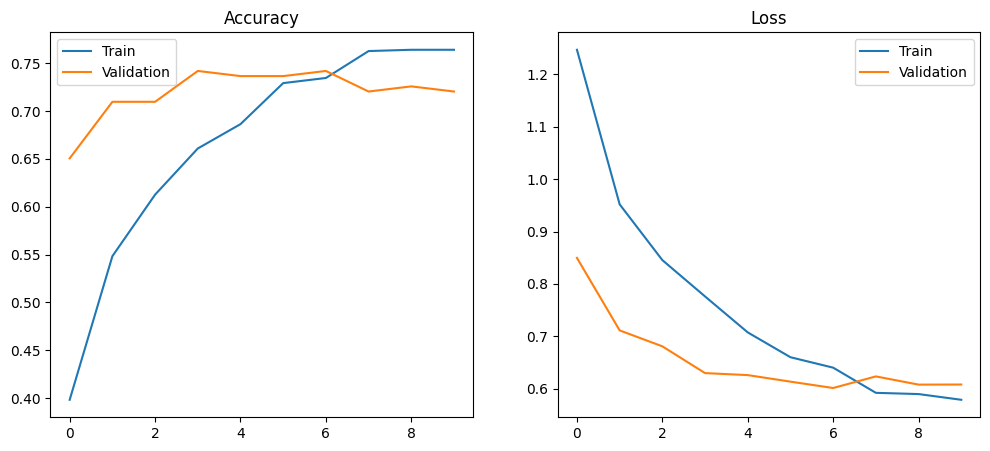

In [74]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_mobile.history['accuracy'])
plt.plot(history_mobile.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(history_mobile.history['loss'])
plt.plot(history_mobile.history['val_loss'])
plt.title("Loss")
plt.legend(["Train","Validation"])

plt.show()

In [75]:
model_mobile.save("rock_type_classifier.keras")

In [76]:
from google.colab import files

files.download("rock_type_classifier.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>